4*2 이미지를 만드는 코드

Best 기준으로 뽑음

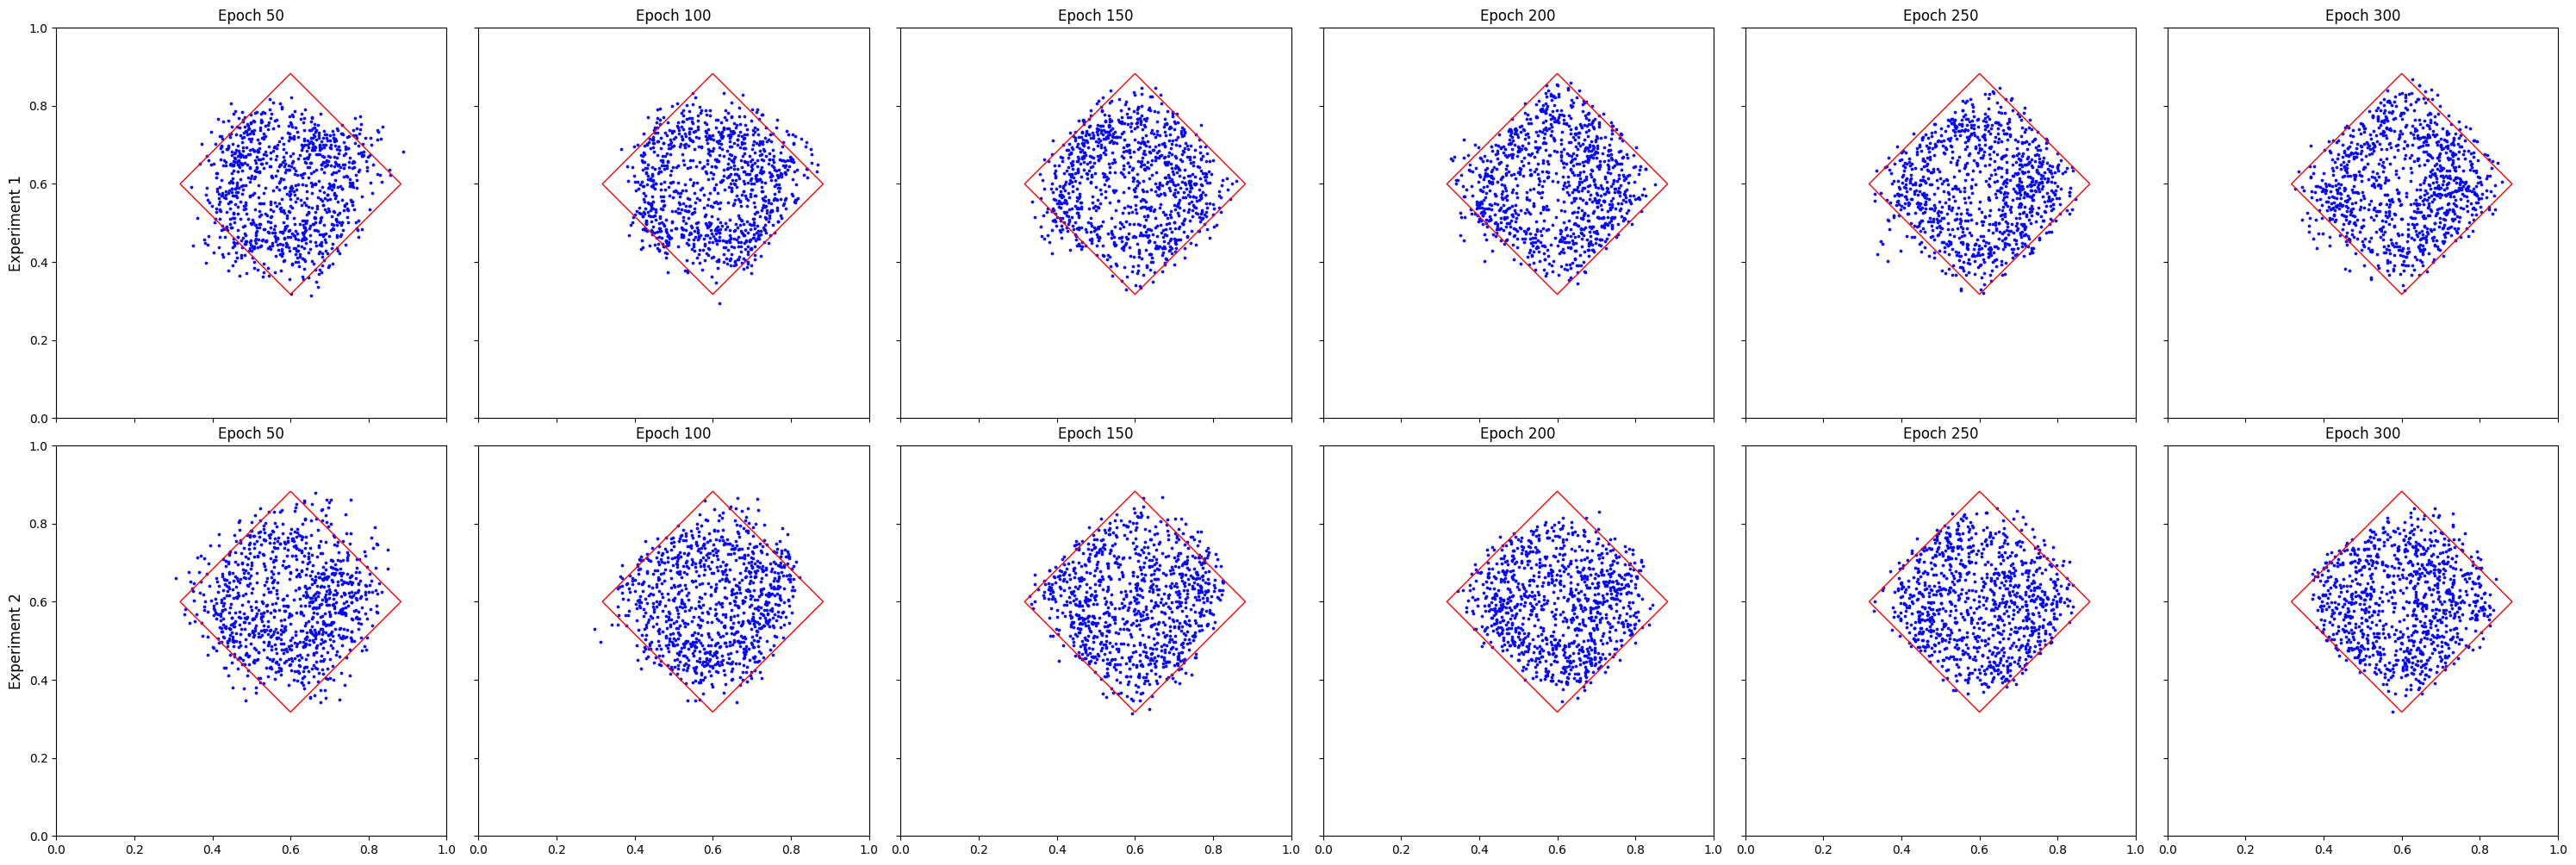

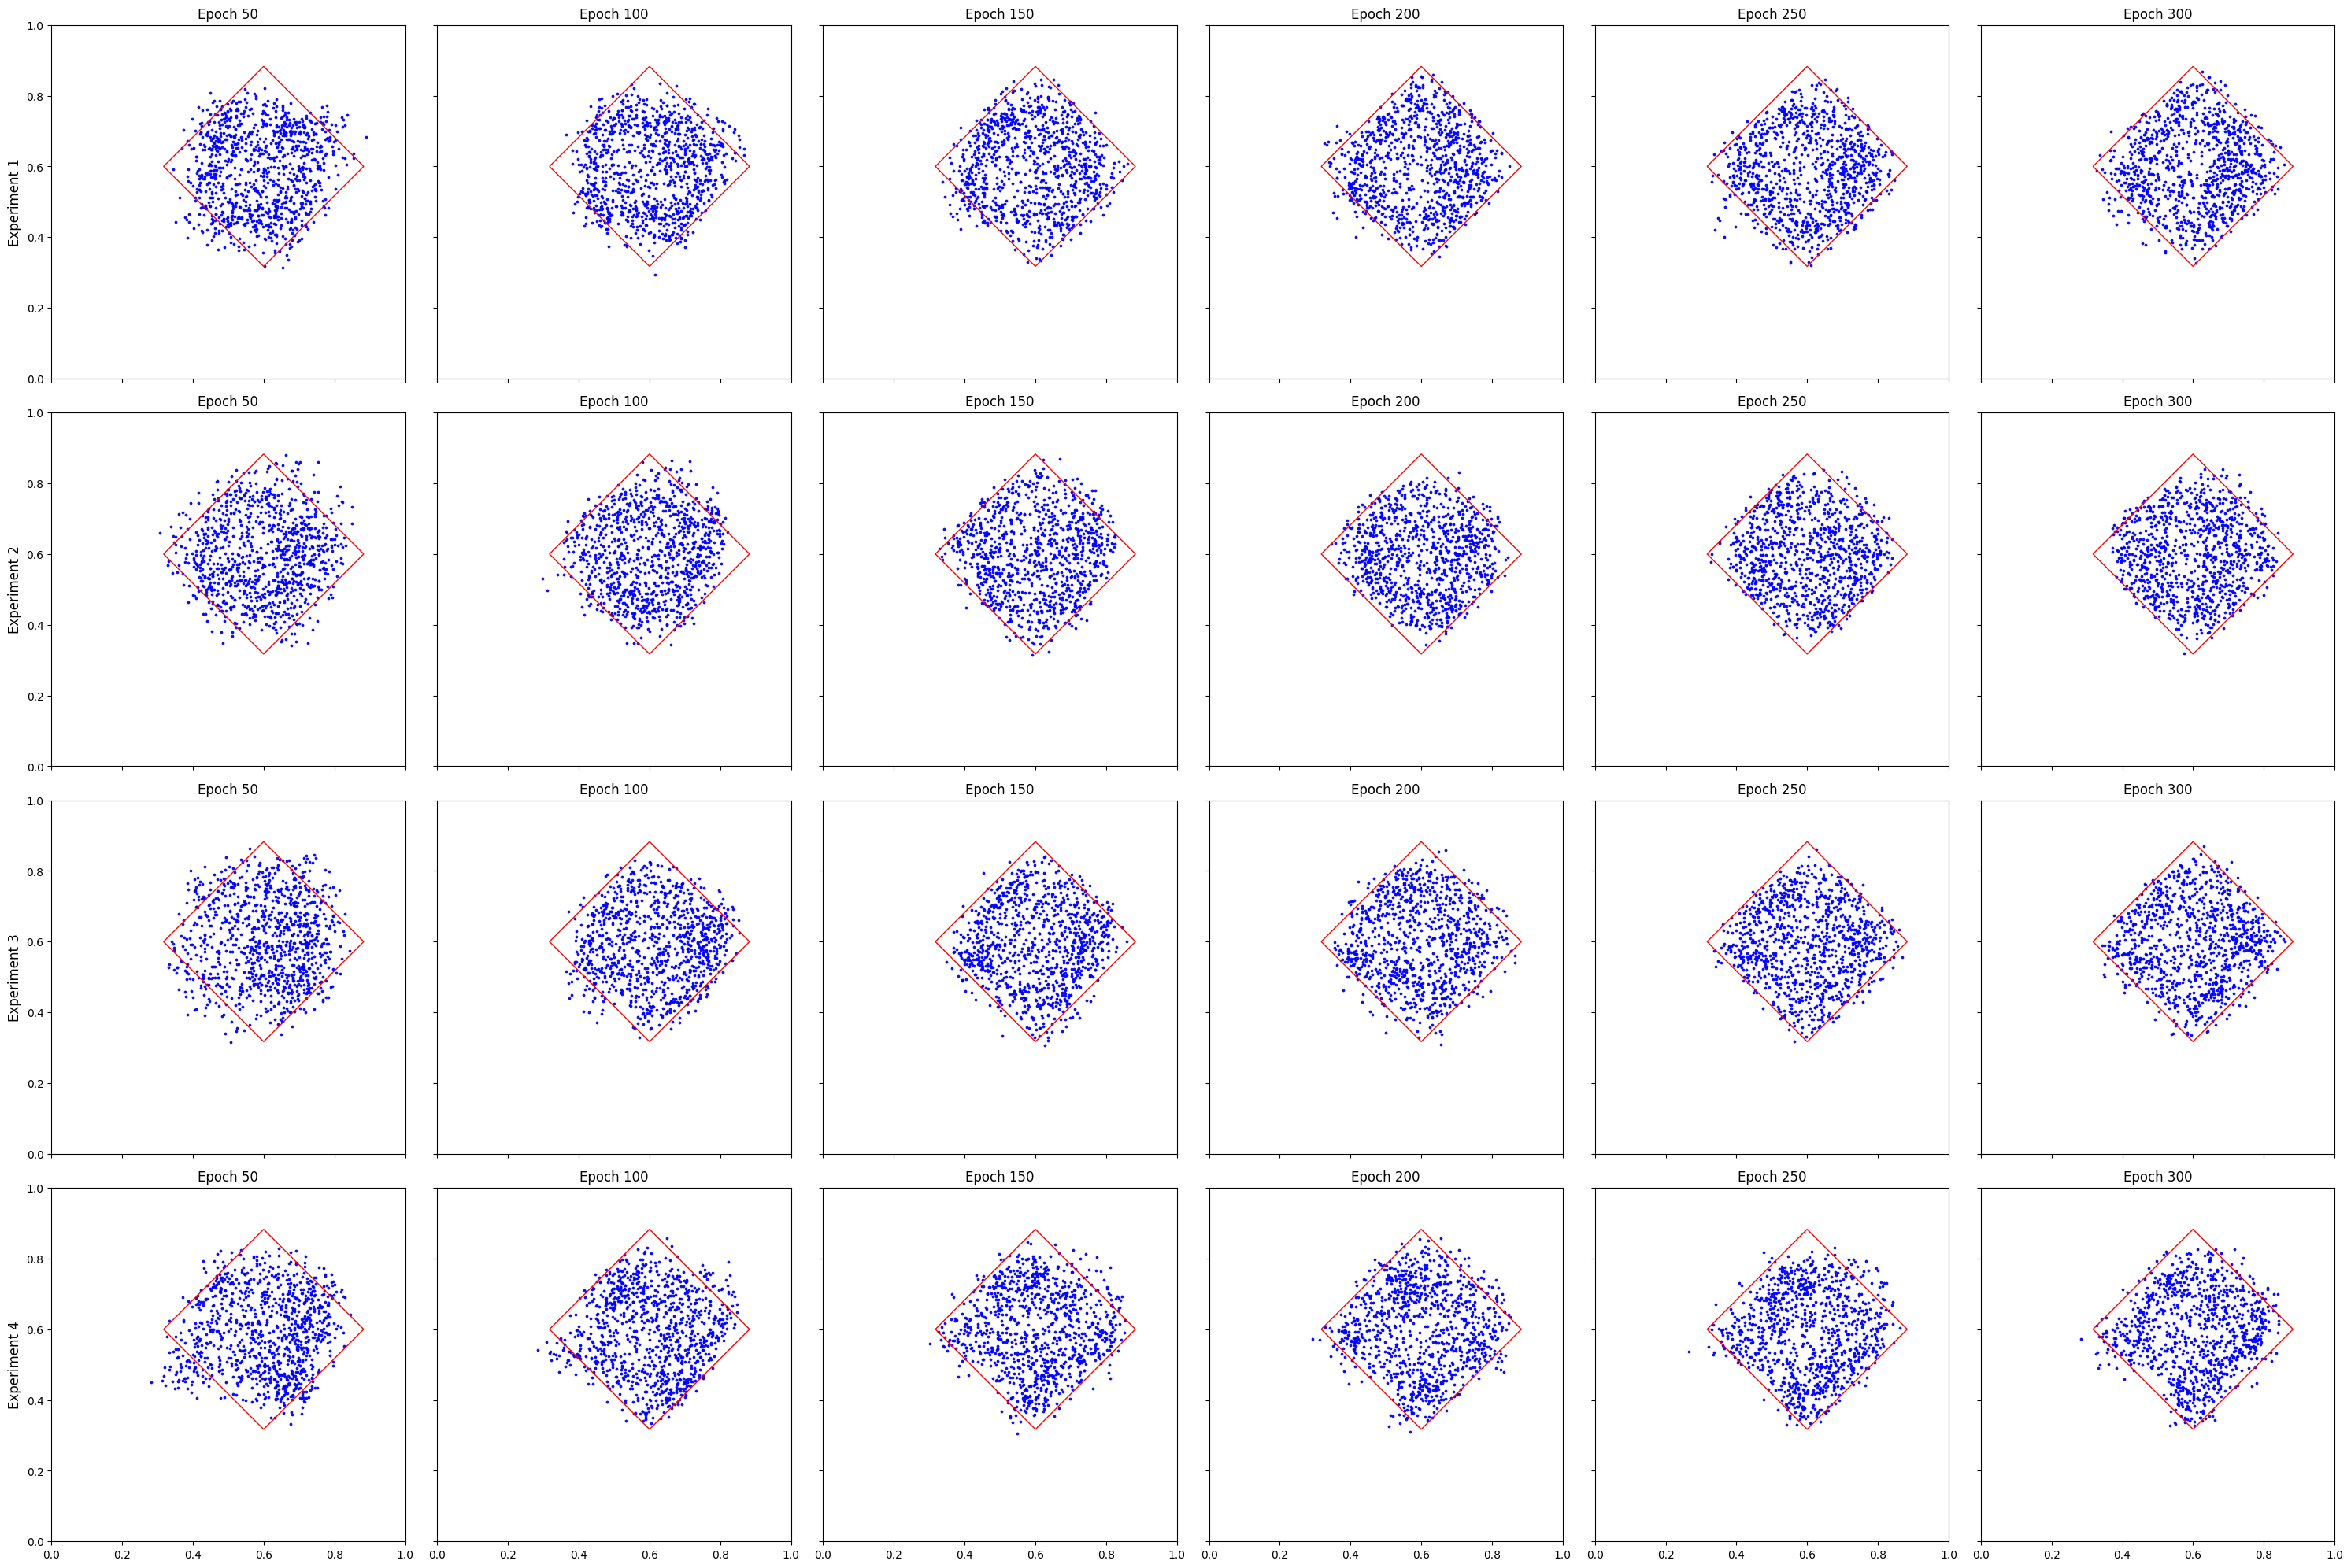

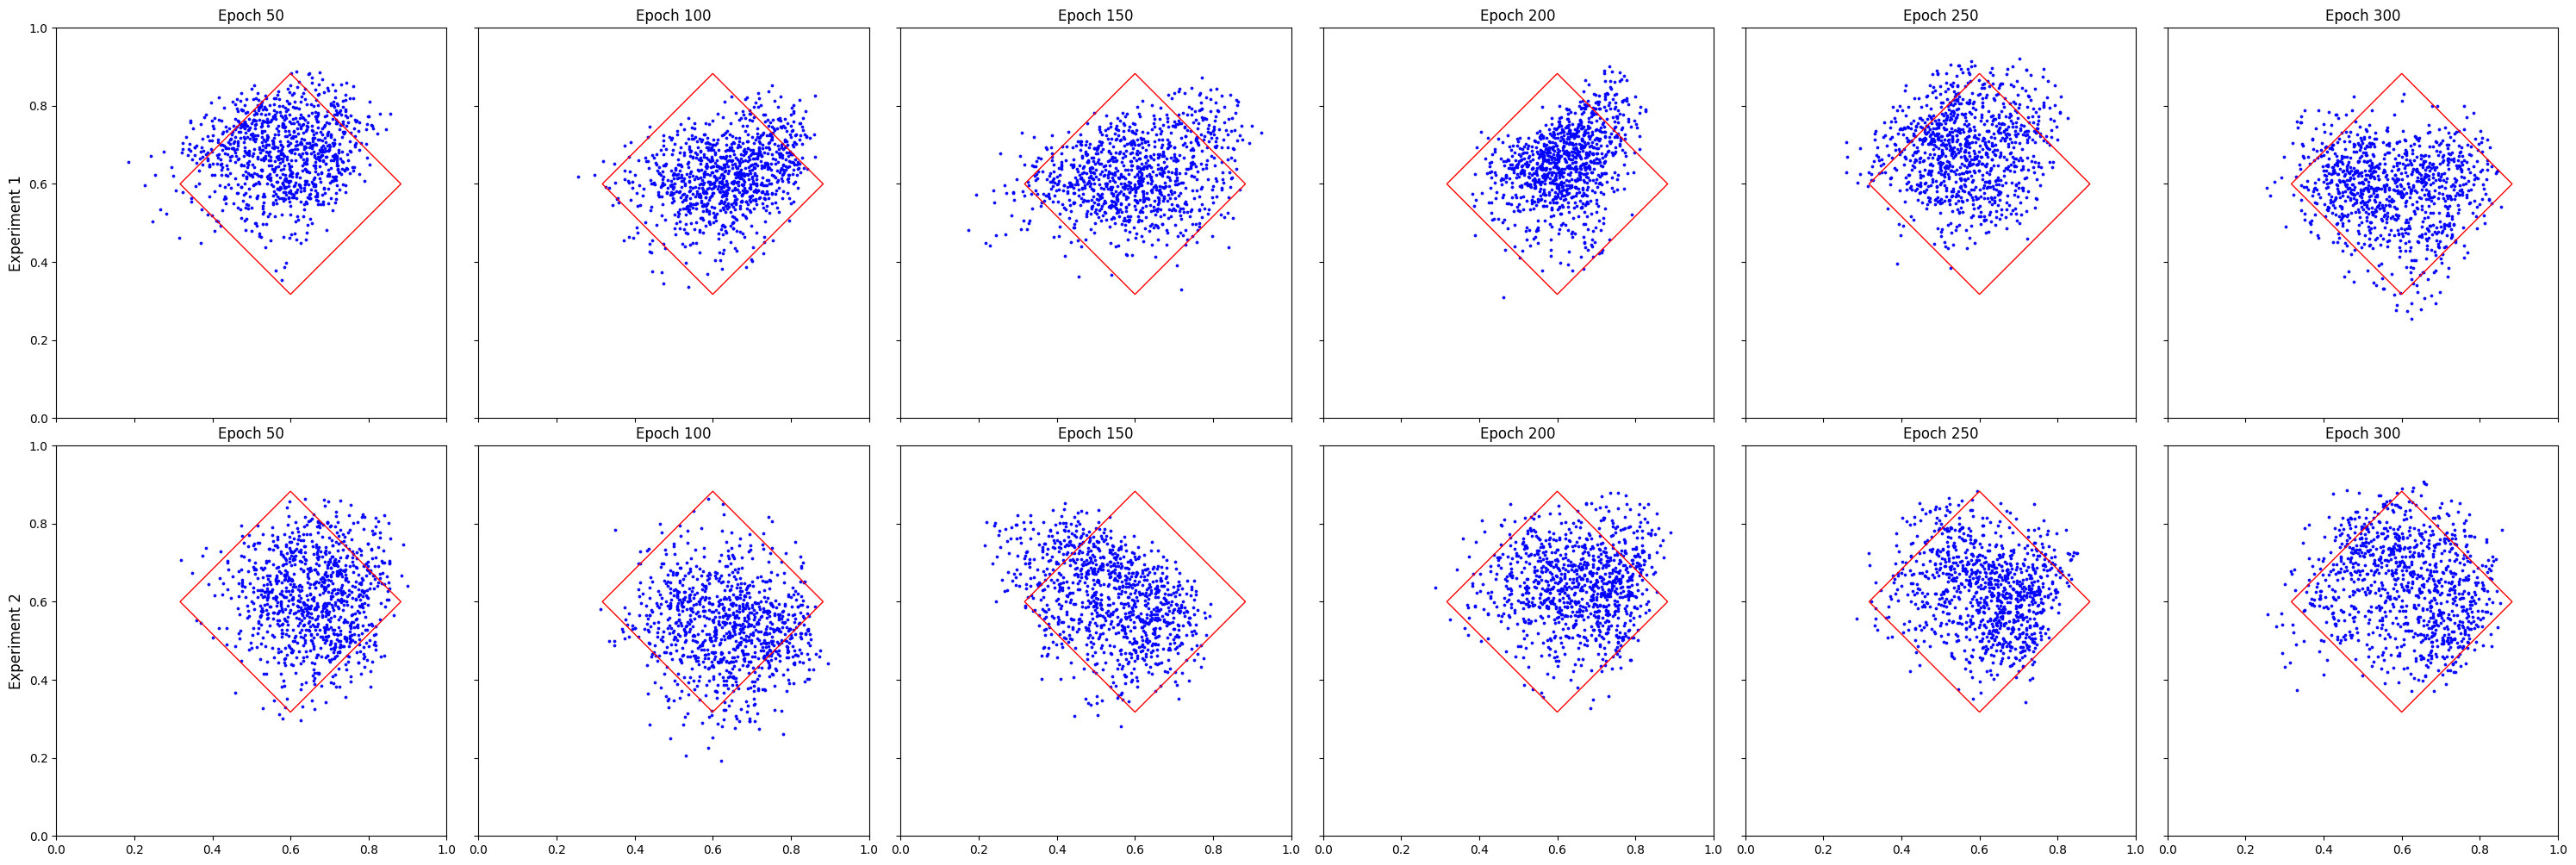

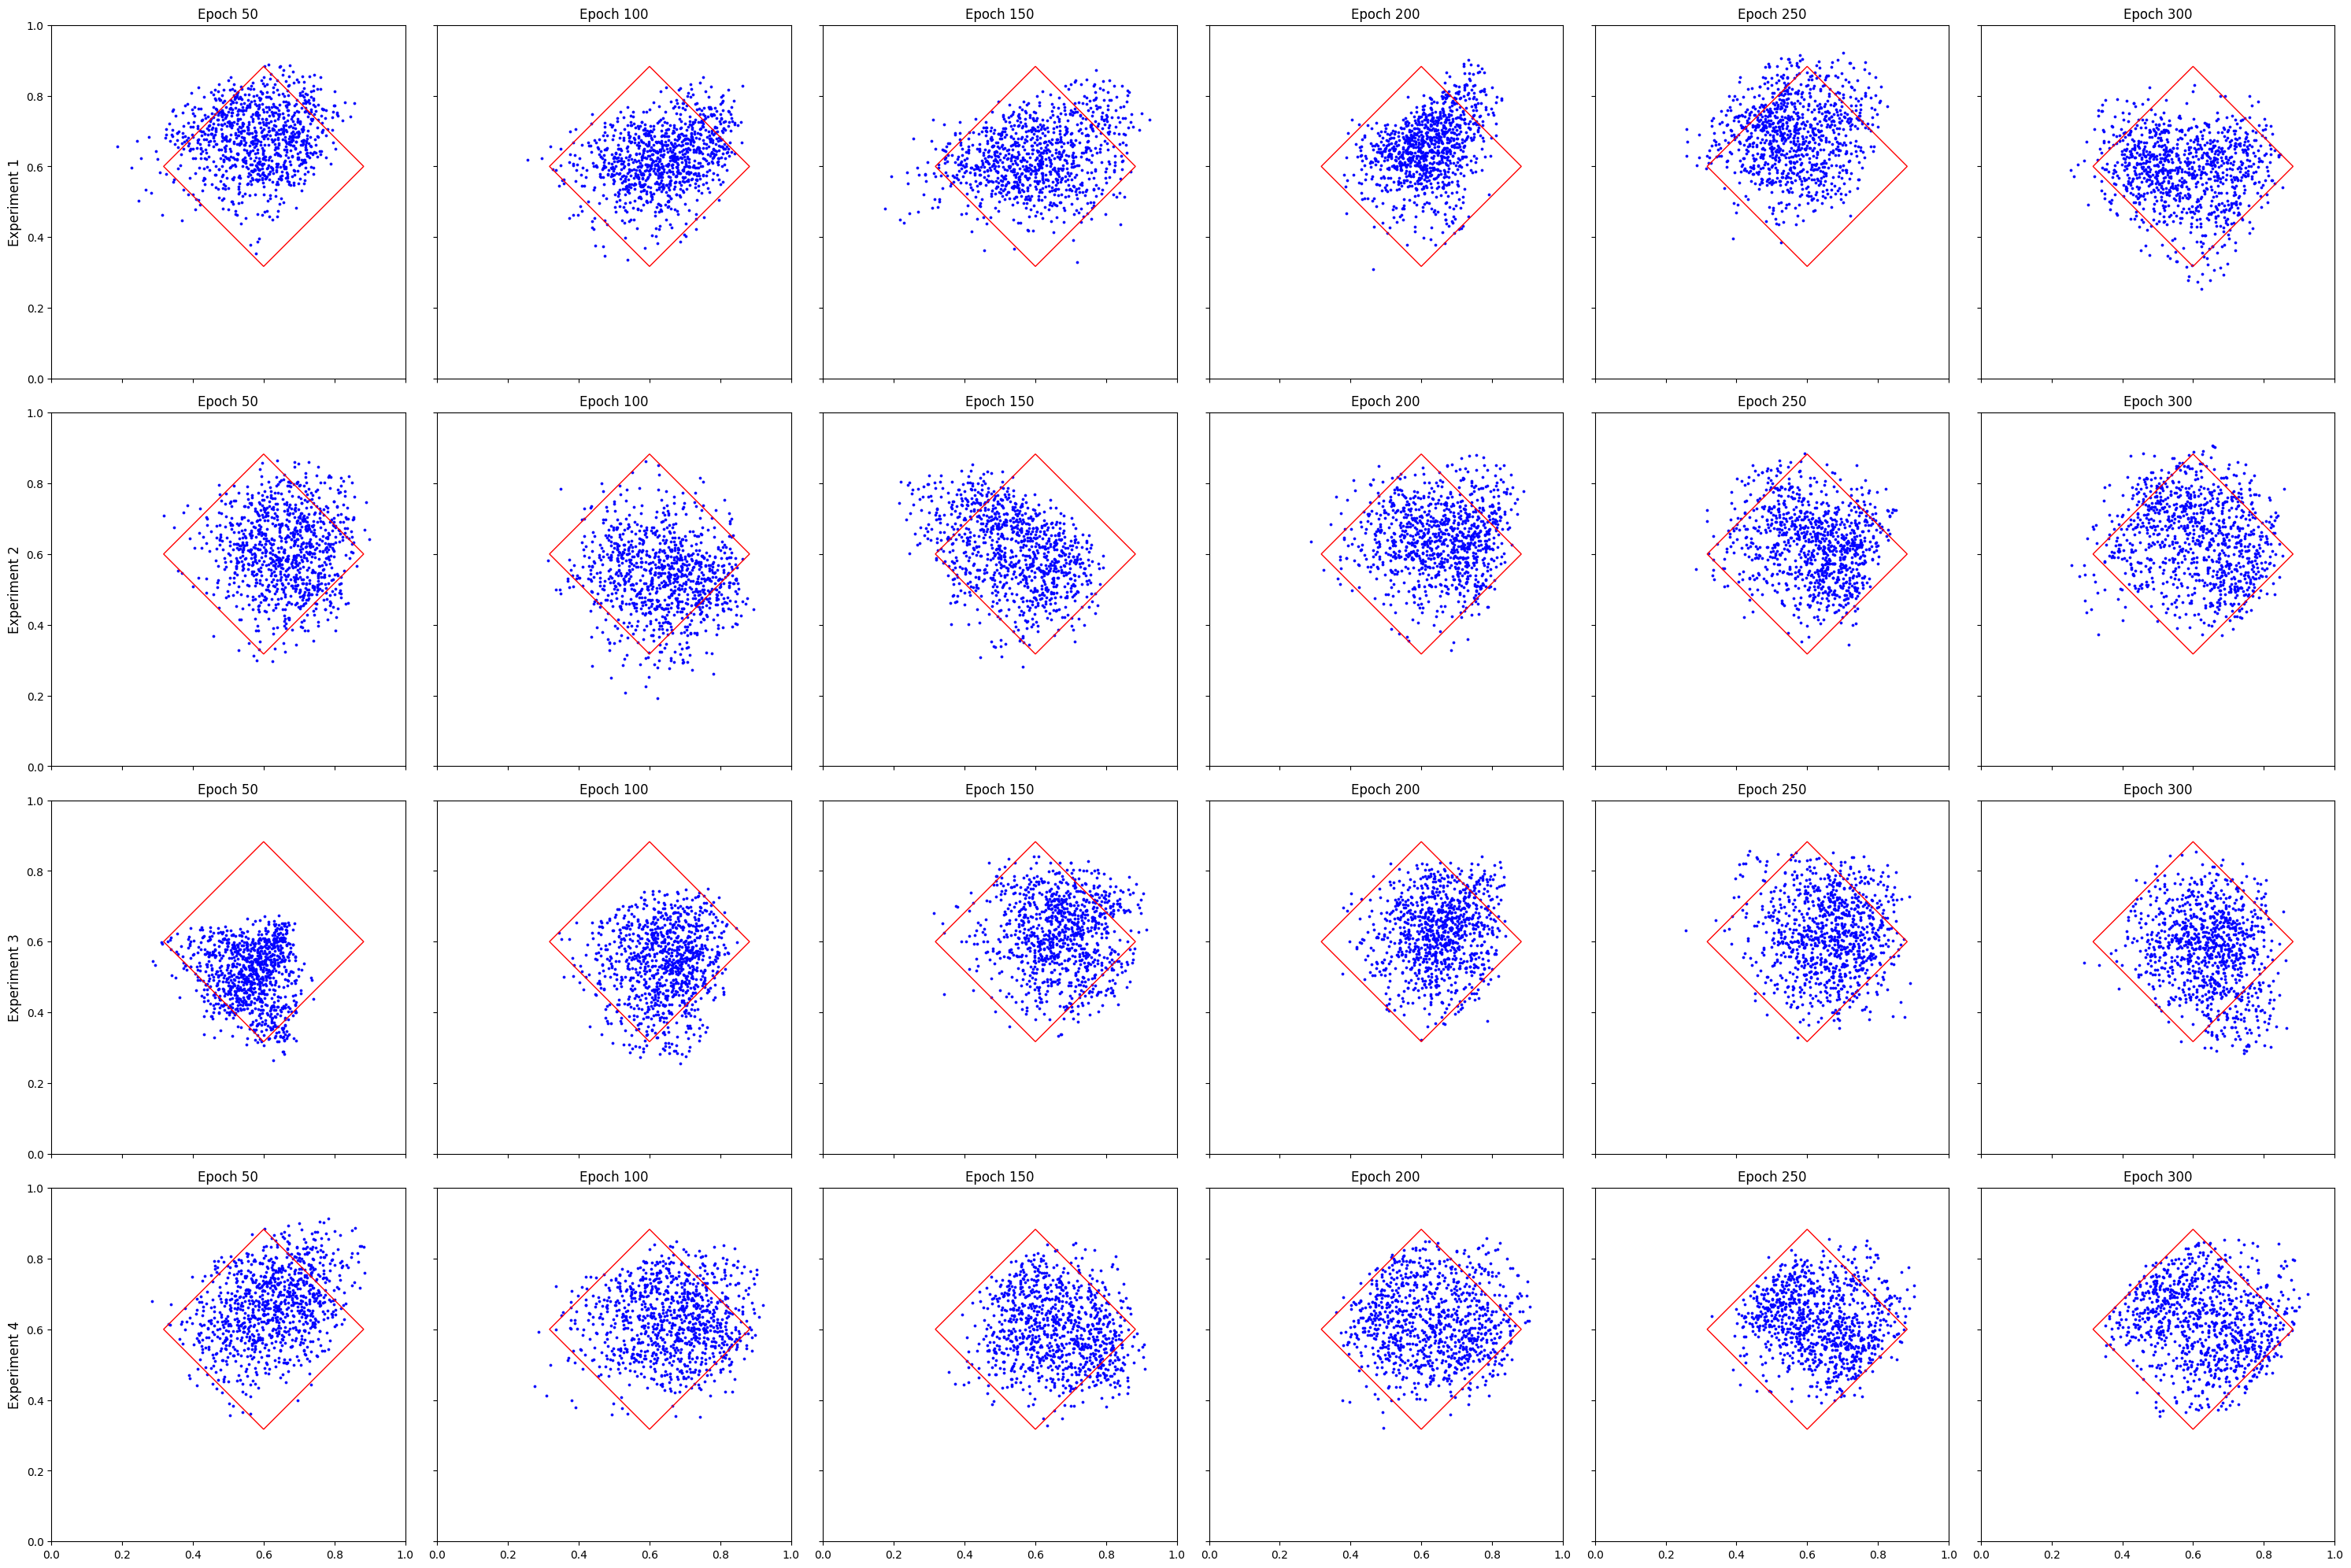

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

result_dir = "../runs"
experiment_names = [ 
    "biased_diamond_1000_True_Oct14_08-59", "biased_diamond_1000_True_Oct14_15-23",
    "biased_diamond_1000_True_Oct15_10-41", "biased_diamond_1000_True_Oct15_10-43",
    "biased_diamond_1000_False_Oct14_08-59", "biased_diamond_1000_False_Oct14_15-23",
    "biased_diamond_1000_False_Oct14_23-07", "biased_diamond_1000_False_Oct15_10-41"
]

# Separate True and False experiments
true_experiments = [name for name in experiment_names if "True" in name]
false_experiments = [name for name in experiment_names if "False" in name]

# Epochs to plot
epochs_to_plot = [50, 100, 150, 200, 250, 300]

# Function to plot experiments
def plot_experiments(experiments, exp_type):
    num_experiments = len(experiments)
    num_epochs = len(epochs_to_plot)
    fig, axes = plt.subplots(nrows=num_experiments, ncols=num_epochs, figsize=(5*num_epochs, 5*num_experiments), squeeze=False)
    
    for row_idx, experiment_name in enumerate(experiments):
        experiment_type = "InfoQGAN" if "True" in experiment_name else "QGAN"
        for col_idx, epoch in enumerate(epochs_to_plot):
            ax = axes[row_idx, col_idx]
            outputs_path = os.path.join(result_dir, experiment_name, f"numpy/gen_outputs_epoch_{epoch}.txt")
            if os.path.exists(outputs_path):
                outputs = np.loadtxt(outputs_path)
                ax.scatter(outputs[:, 0], outputs[:, 1], color='blue', s=3, alpha=0.9)
            else:
                print(f"Data file {outputs_path} not found.")
                ax.text(0.5, 0.5, 'Data not found', horizontalalignment='center', verticalalignment='center')
            ax.set_title(f'Epoch {epoch}')
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.set_aspect('equal')
            if col_idx != 0:
                ax.tick_params(labelleft=False)
            if row_idx != num_experiments - 1:
                ax.tick_params(labelbottom=False)
            # Add diamond
            arm = 0.2 * np.sqrt(2)
            diamond = patches.Polygon([[0.6+arm, 0.6], [0.6, 0.6-arm], [0.6-arm, 0.6], [0.6, 0.6+arm]], closed=True, fill=False, edgecolor='red')
            ax.add_patch(diamond)
        # Label the row with the experiment name
        ax = axes[row_idx, 0]
        ax.set_ylabel(f"Experiment {row_idx+1}", rotation=90, size='large')
    plt.tight_layout()
    # 현재 경로에도 사진 저장 (이후 visualize로 올려 주세요)
    fig.savefig(f"tmp/2D_mode_collapse_{experiment_type}_{num_experiments}row.png")
    plt.show()

# Plot True experiments
plot_experiments(true_experiments[:2], exp_type='True')
plot_experiments(true_experiments, exp_type='True')

# Plot False experiments
plot_experiments(false_experiments[:2 ], exp_type='False')
plot_experiments(false_experiments, exp_type='False')


마지막 결과를 출력

False, max p-value: 0.1588134126704357 at epoch 300
True, max p-value: 0.1588134126704357 at epoch 300
False, max p-value: 0.1588134126704357 at epoch 300
True, max p-value: 0.1588134126704357 at epoch 300


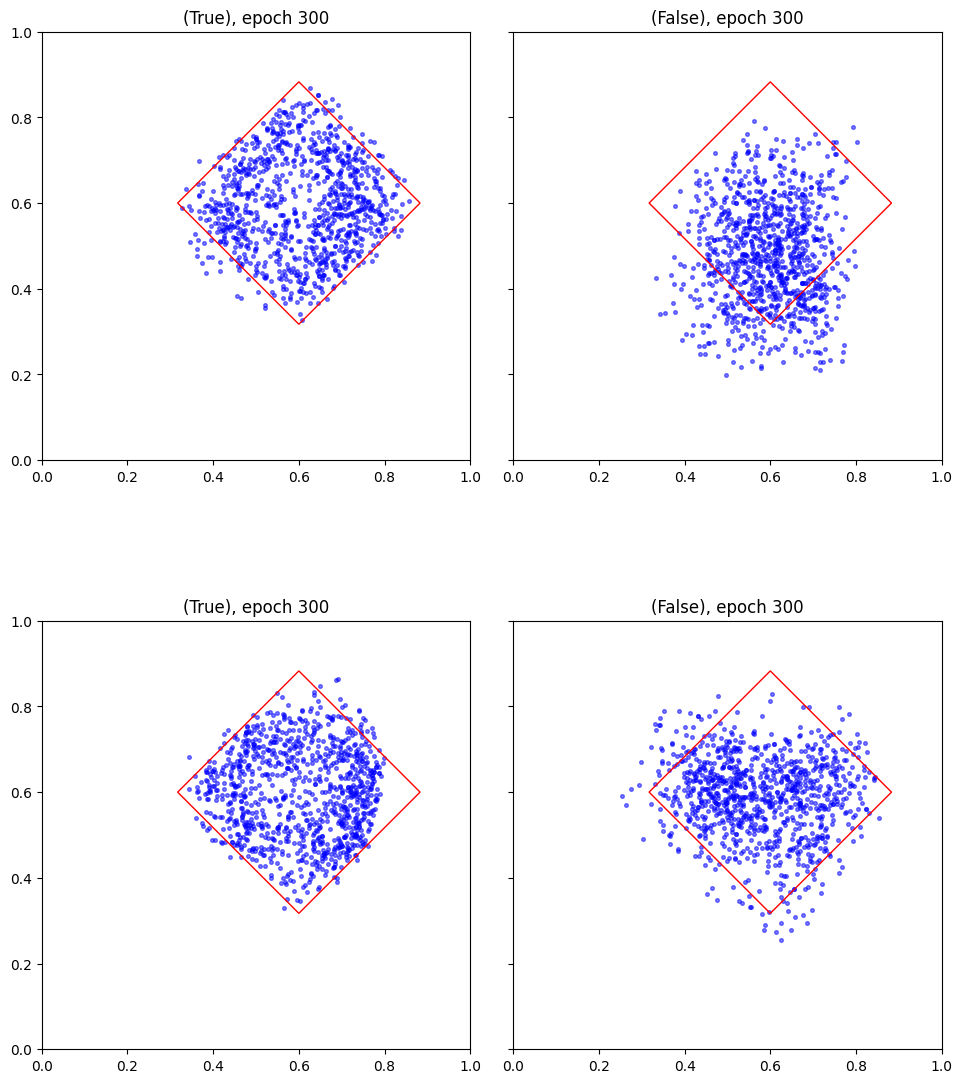

In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

result_dir = "../runs"
experiment_names = [ 
    "biased_diamond_1000_False_Oct14_08-58", "biased_diamond_1000_True_Oct14_08-59",
    "biased_diamond_1000_False_Oct14_08-59", "biased_diamond_1000_True_Oct14_09-02",
]

# True와 False 실험별로 인덱스를 관리합니다.
true_idx = 0
false_idx = 0

# 전체 figure와 axes를 생성합니다.
experiment_num = len(experiment_names)//2
fig, axes = plt.subplots(experiment_num, 2, figsize=(10, 2+5*experiment_num), gridspec_kw={'wspace': 0.1})

for idx, experiment_name in enumerate(experiment_names):
    experiment_path = os.path.join(result_dir, experiment_name, f"{experiment_name}.csv")

    df = None
    if os.path.exists(experiment_path):
        # 파일이 존재하면 읽어옵니다.
        df = pd.read_csv(experiment_path)
        #print(f"Loaded {experiment_name}.csv")
    else:
        # 파일이 없으면 'scalars.csv'를 시도합니다.
        scalars_path = os.path.join(result_dir, experiment_name, "scalars.csv")
        if os.path.exists(scalars_path):
            df = pd.read_csv(scalars_path)
            print(f"{experiment_name}.csv not found. Loaded scalars.csv instead.")
        else:
            print(f"Neither {experiment_name}.csv nor scalars.csv found.")
            continue  # 파일이 없으면 다음 실험으로 넘어갑니다.

    # 데이터 파일 경로 설정
    outputs_path = os.path.join(result_dir, experiment_name, f"numpy/gen_outputs_epoch_{len(df)}.txt")

    # 데이터가 존재하는지 확인
    if not os.path.exists(outputs_path):
        print(f"Data files for epoch {len(df)} not found in {outputs_path}.")
        continue  # 데이터가 없으면 다음 실험으로 넘어갑니다.

    # 데이터 로드
    outputs = np.loadtxt(outputs_path)

    # 플롯할 축 선택
    if "True" in experiment_name:
        row_idx = true_idx
        col_idx = 0  # 왼쪽 열은 True 실험
        true_idx += 1
        exp_type = "True"
    else:
        row_idx = false_idx
        col_idx = 1  # 오른쪽 열은 False 실험
        false_idx += 1
        exp_type = "False"

    ax = axes[row_idx, col_idx]

    # 단색으로 플롯 (파란색 점)
    ax.scatter(outputs[:, 0], outputs[:, 1], color='blue', s=7, alpha=0.5)
    ax.set_title(f'({exp_type}), epoch {len(df)}')

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')

    # y축 레이블 제거 (오른쪽 열에 대해서만)
    if col_idx == 1:
        ax.tick_params(labelleft=False)

    # 중심 (0.6, 0.6), 팔 길이 0.2sqrt(2)인 다이아몬드 추가
    arm = 0.2 * np.sqrt(2)
    circle = patches.Polygon([[0.6+arm, 0.6], [0.6, 0.6-arm], [0.6-arm, 0.6], [0.6, 0.6+arm]], closed=True, fill=False, edgecolor='red')
    ax.add_patch(circle)

    
    print(f"{exp_type}, max p-value: {max_p_value} at epoch {len(df)}")

# 레이아웃 조정 및 이미지 저장
fig.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.05)

# 현재 경로에도 사진 저장 (이후 visualize로 올려 주세요)
fig.savefig("tmp/mode_collapse_diamond_last.png")

plt.show()
